## GW32 — Premier League npxG Trends

10-game rolling npxG for/against for all 20 PL teams.

In [1]:
import sys, sqlite3
import pandas as pd
import numpy as np

sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.npxg_trend_chart import plot_xg_trend

DB_PATH = '/Users/admin/dev/algobetting/infra/data/db/fotmob.db'
LEAGUE  = 'Premier_League'

conn = sqlite3.connect(DB_PATH)

# 1. npxG per team per match
xg = pd.read_sql("""
    SELECT match_id, match_date, teamId AS team_id, team_name,
           SUM(expectedGoals) AS xg_for
    FROM np_shots
    WHERE league_id = 'Premier_League'
    GROUP BY match_id, teamId, team_name
""", conn)

# 2. Matches for opponent lookup + season
matches = pd.read_sql("""
    SELECT match_id, home_team, away_team, season
    FROM matches
    WHERE league_id = 'Premier_League'
""", conn)
conn.close()

# 3. Opponent lookup (integer team_id joins)
opp_home = matches[['match_id','home_team','away_team']].rename(
    columns={'home_team': 'team_id', 'away_team': 'opponent_id'})
opp_away = matches[['match_id','away_team','home_team']].rename(
    columns={'away_team': 'team_id', 'home_team': 'opponent_id'})
opp_lookup = pd.concat([opp_home, opp_away])
xg = xg.merge(opp_lookup, on=['match_id', 'team_id'], how='left')

# 4. Opponent xG as xG against
xg_against = xg[['match_id', 'team_id', 'xg_for']].rename(
    columns={'team_id': 'opponent_id', 'xg_for': 'xg_against'})
xg = xg.merge(xg_against, on=['match_id', 'opponent_id'], how='left')

# 5. Add season + sort
xg = xg.merge(matches[['match_id', 'season']].drop_duplicates(), on='match_id', how='left')
xg['match_date'] = pd.to_datetime(xg['match_date'])
xg = xg.sort_values(['team_id', 'match_date']).reset_index(drop=True)

# 6. 10-game rolling averages per team
xg['xg_for_roll10']     = xg.groupby('team_id')['xg_for'].transform(
    lambda x: x.rolling(10, min_periods=3).mean())
xg['xg_against_roll10'] = xg.groupby('team_id')['xg_against'].transform(
    lambda x: x.rolling(10, min_periods=3).mean())

teams_loaded = sorted(xg['team_name'].dropna().unique().tolist())
print(f"Loaded {len(teams_loaded)} teams, {xg['match_id'].nunique()} unique matches")
print(teams_loaded)
xg[['team_name','match_date','xg_for','xg_against','xg_for_roll10','xg_against_roll10']].tail(10)

Loaded 20 teams, 318 unique matches
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man United', 'Newcastle', 'Nottm Forest', 'Sunderland', 'Tottenham', 'West Ham', 'Wolves']


,team_name,match_date,xg_for,xg_against,xg_for_roll10,xg_against_roll10
626,Newcastle,2026-01-25,2.175433,1.162148,1.625310,0.868492
627,Newcastle,2026-01-31,0.370065,2.282179,1.536874,1.025823
628,Newcastle,2026-02-07,1.455043,0.999575,1.584497,1.044352
629,Newcastle,2026-02-10,2.499011,1.800704,1.810184,1.194835
630,Newcastle,2026-02-21,0.623458,1.651751,1.623560,1.238085
631,Newcastle,2026-02-28,1.045883,1.740281,1.610347,1.285059
632,Newcastle,2026-03-04,1.693761,1.488822,1.472365,1.323971
633,Newcastle,2026-03-14,1.381801,1.386501,1.386034,1.390238
634,Newcastle,2026-03-22,1.289232,2.984350,1.348321,1.578321
635,Newcastle,2026-04-12,1.123212,1.803782,1.365690,1.730009


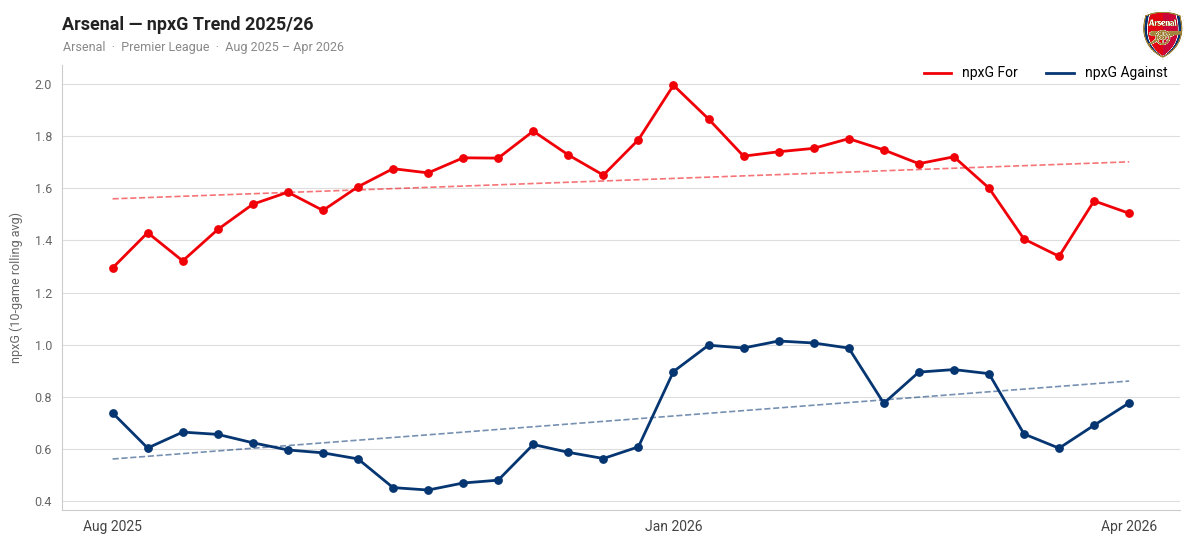

In [2]:
team = 'Arsenal'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/arsenal_npxg.png',
)

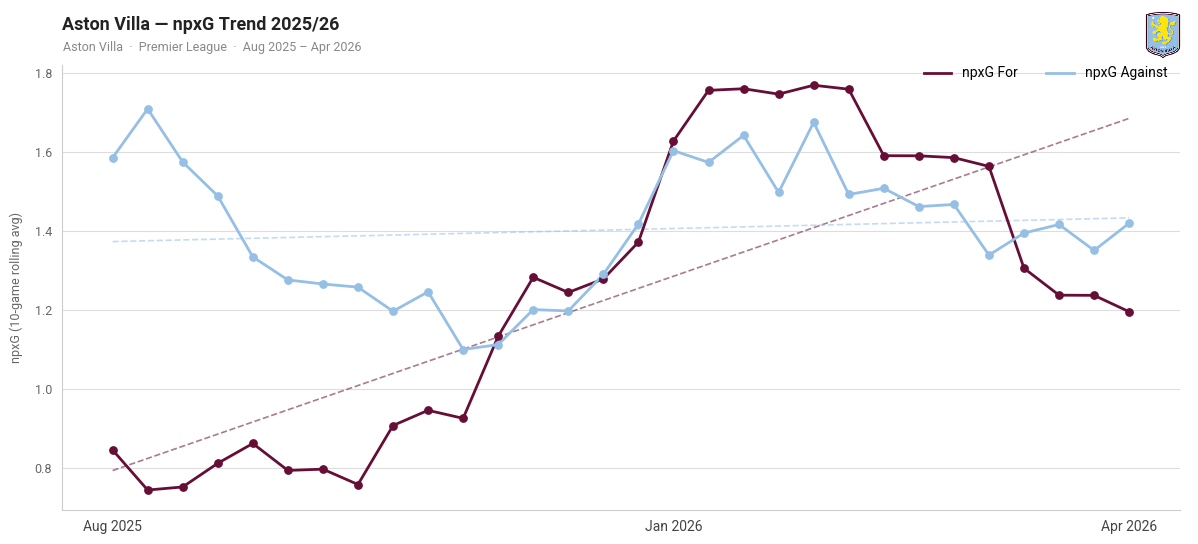

In [3]:
team = 'Aston Villa'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/aston_villa_npxg.png',
)

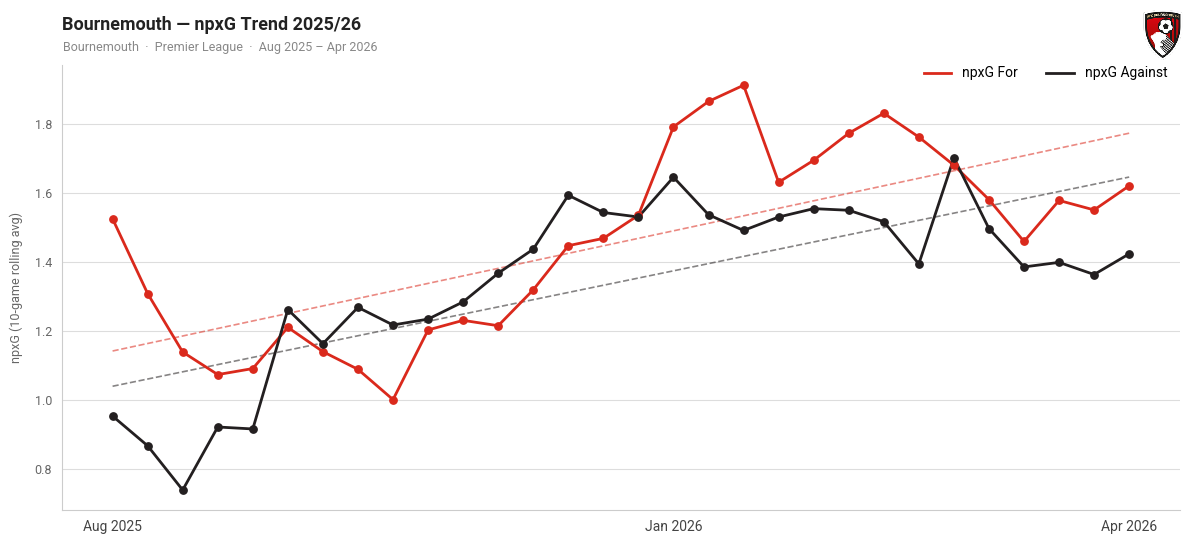

In [4]:
team = 'Bournemouth'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/bournemouth_npxg.png',
)

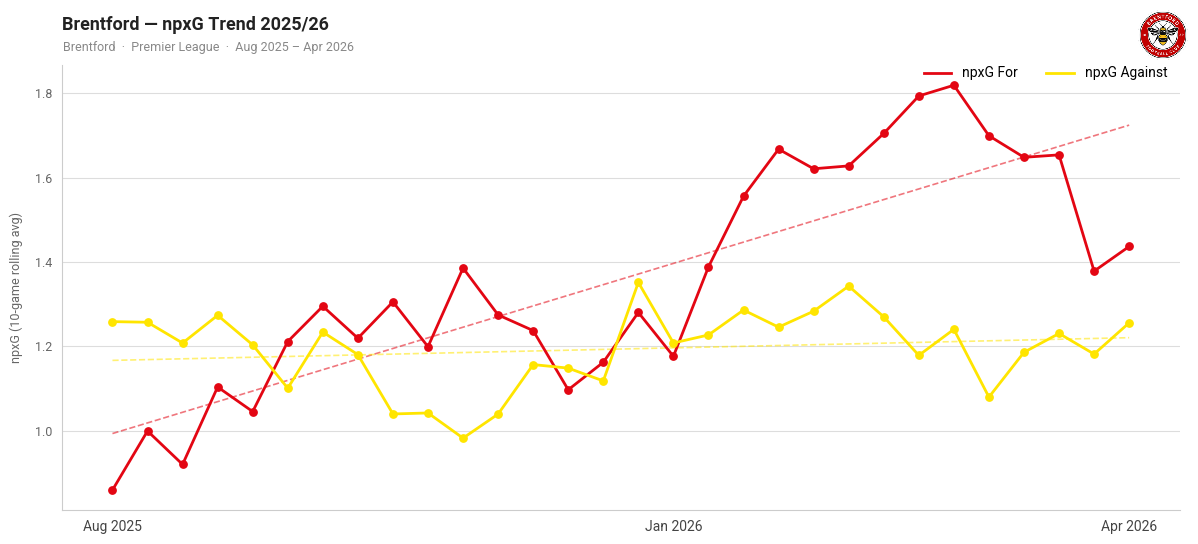

In [5]:
team = 'Brentford'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/brentford_npxg.png',
)

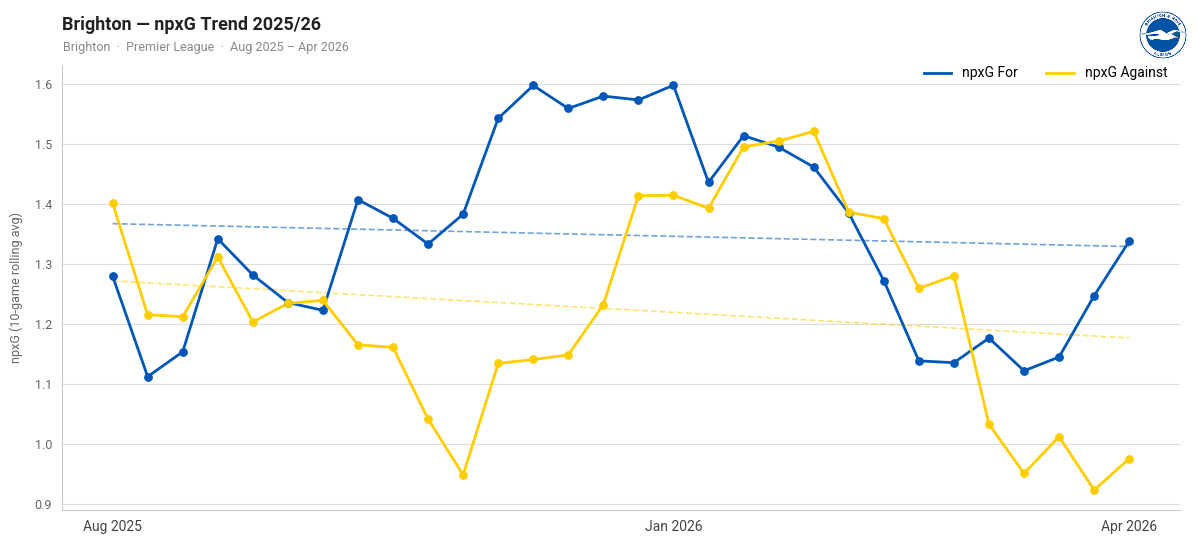

In [6]:
team = 'Brighton'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/brighton_npxg.png',
)

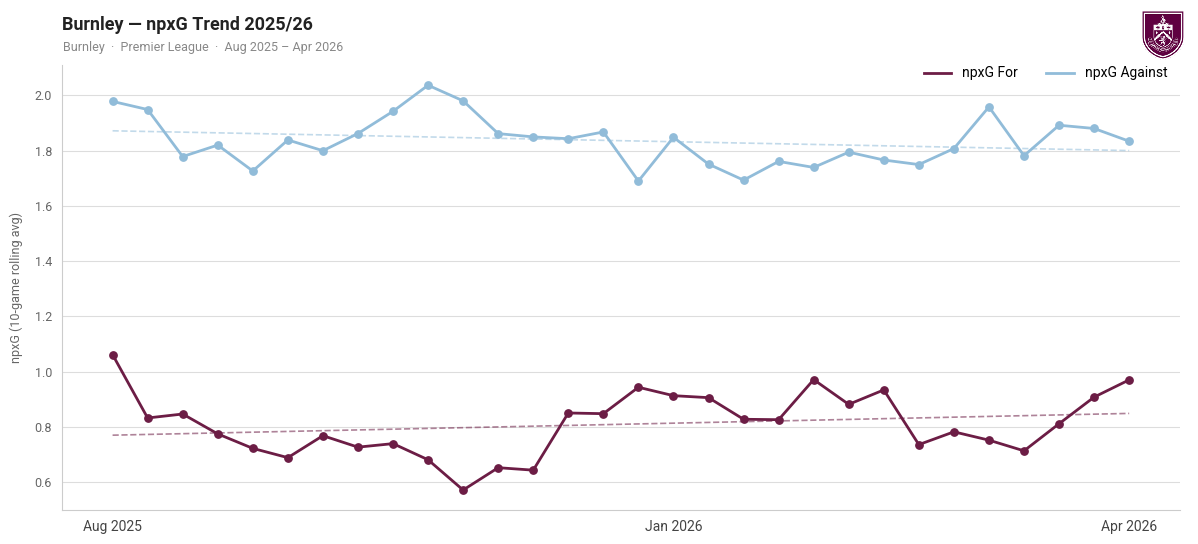

In [7]:
team = 'Burnley'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/burnley_npxg.png',
)

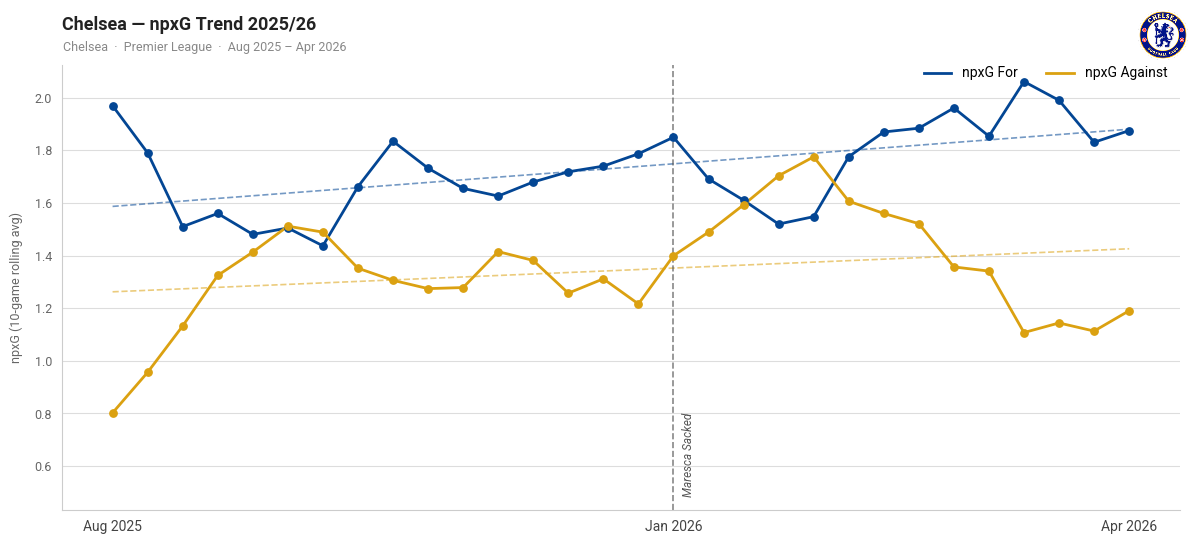

In [26]:
team = 'Chelsea'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    annotations=[('2026-01-01', 'Maresca Sacked')],
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/chelsea_npxg.png',
)

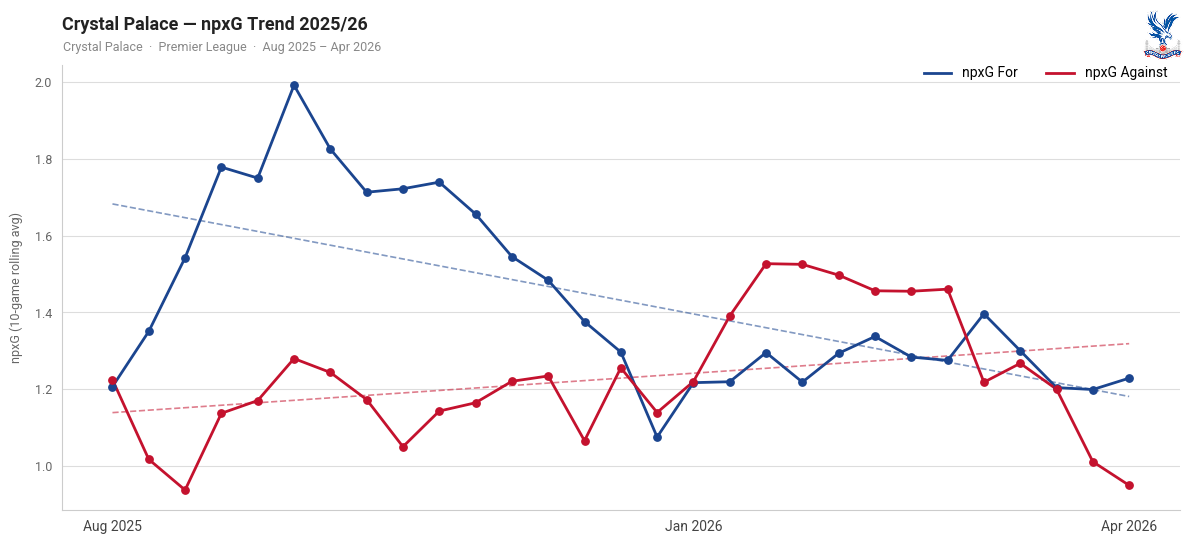

In [9]:
team = 'Crystal Palace'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/crystal_palace_npxg.png',
)

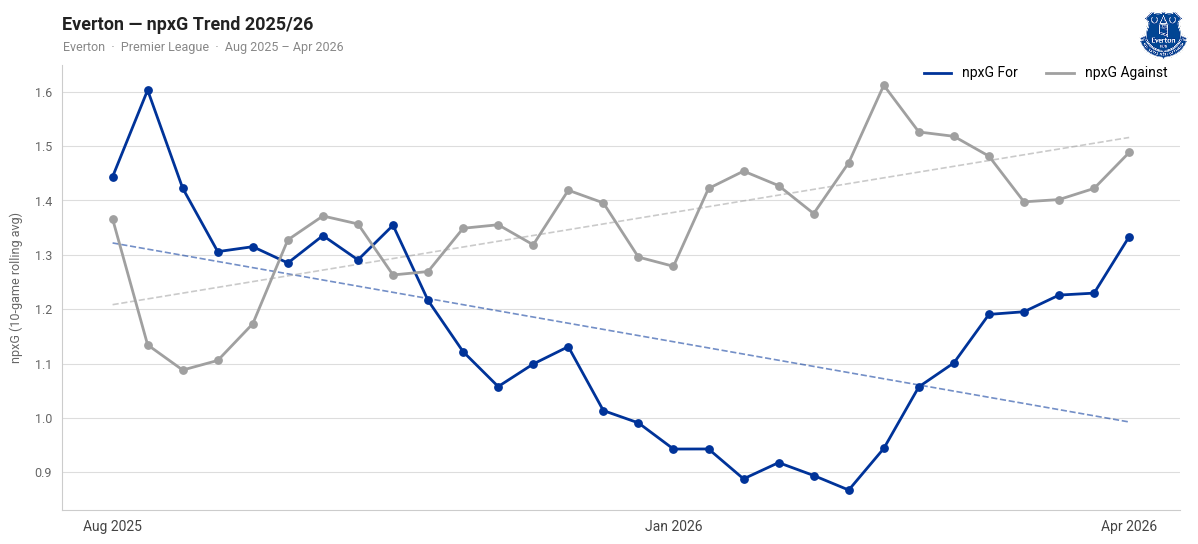

In [10]:
team = 'Everton'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/everton_npxg.png',
)

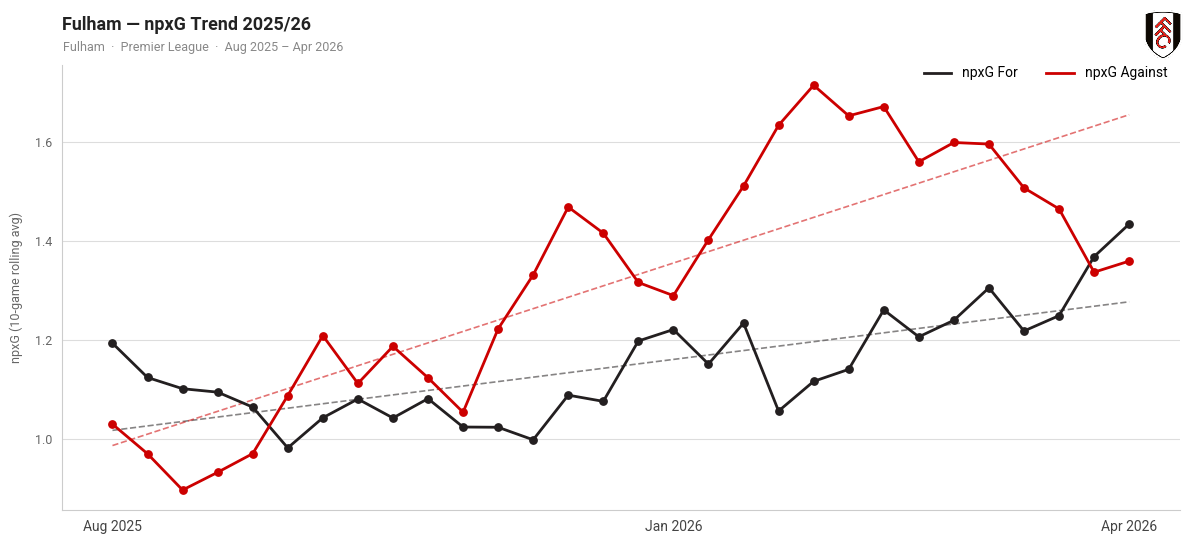

In [11]:
team = 'Fulham'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/fulham_npxg.png',
)

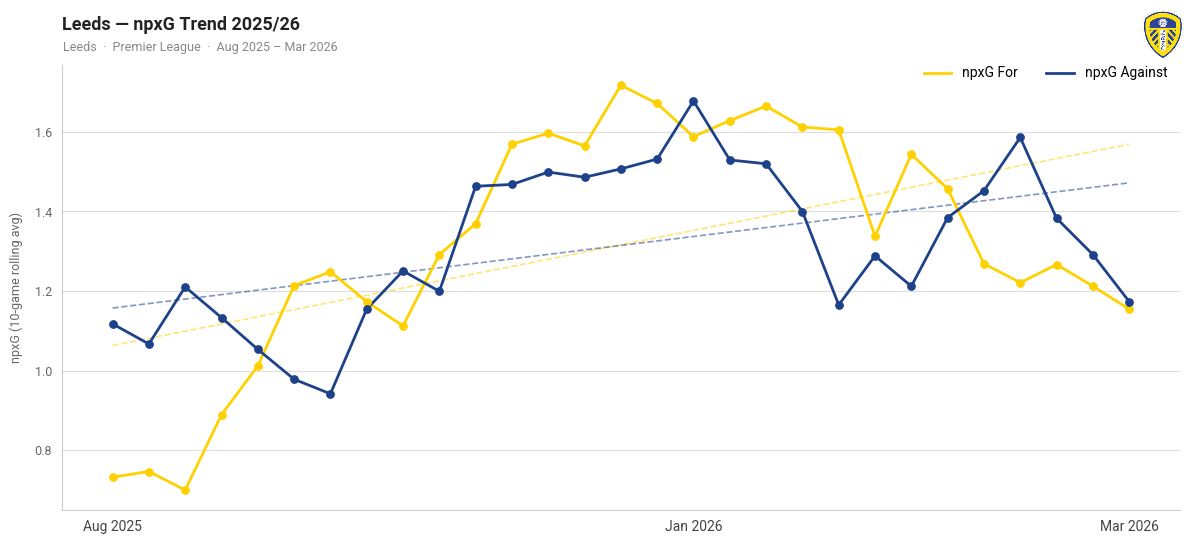

In [12]:
team = 'Leeds'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/leeds_npxg.png',
)

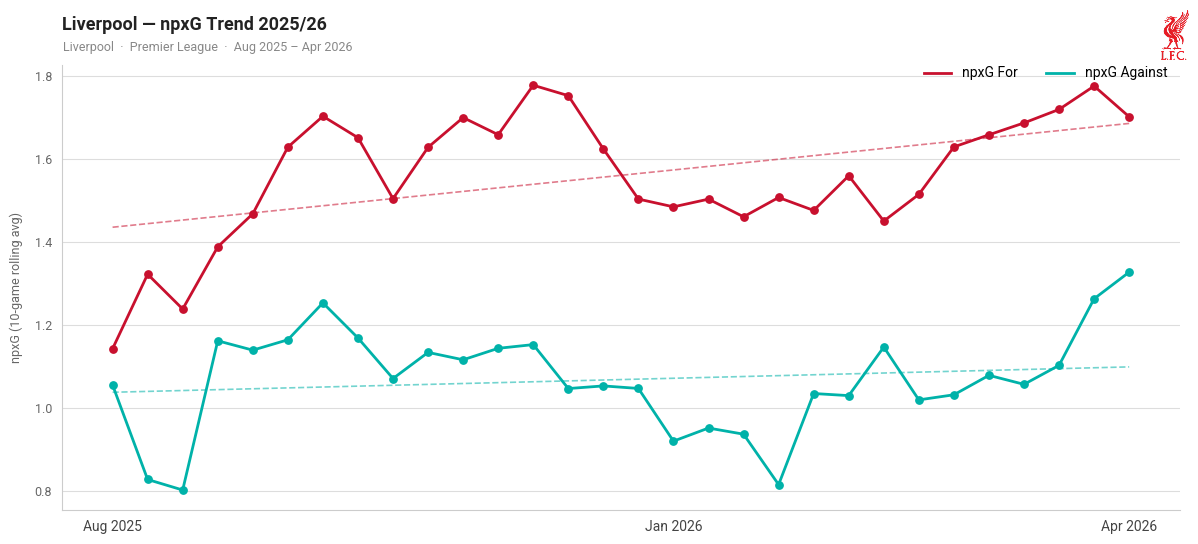

In [24]:
team = 'Liverpool'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/liverpool_npxg.png',
)


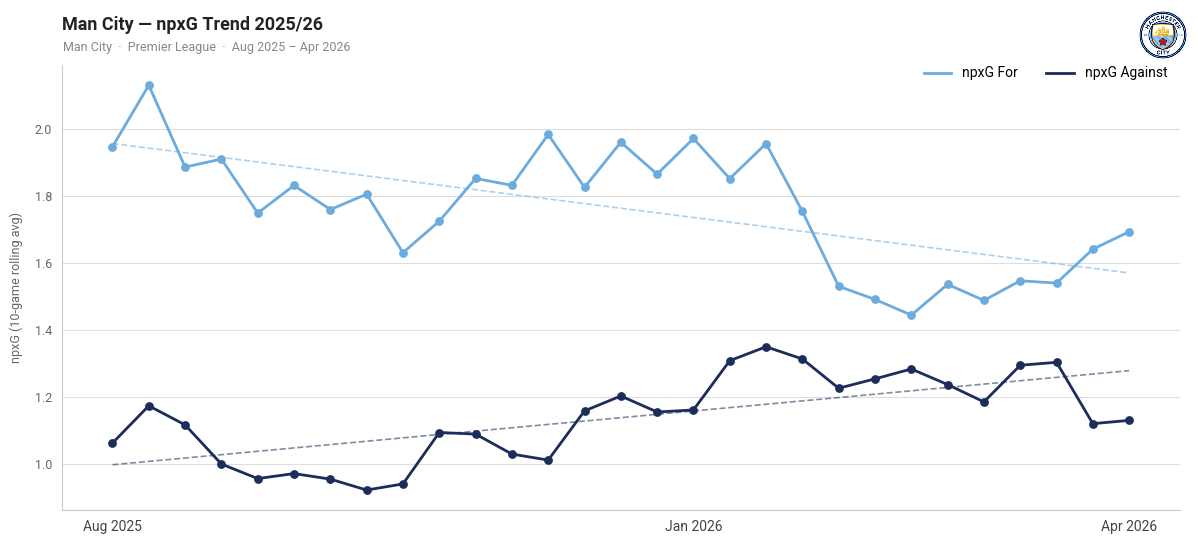

In [22]:
team = 'Man City'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/man_city_npxg.png',
)


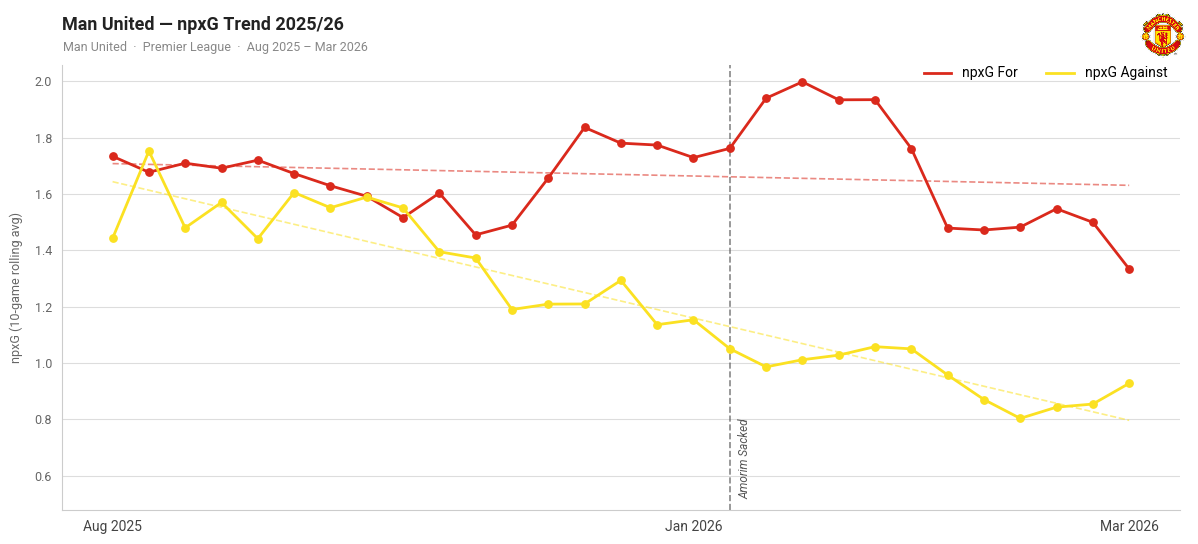

In [28]:
team = 'Man United'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    annotations = [('2026-01-05', 'Amorim Sacked')],
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/man_united_npxg.png',
)

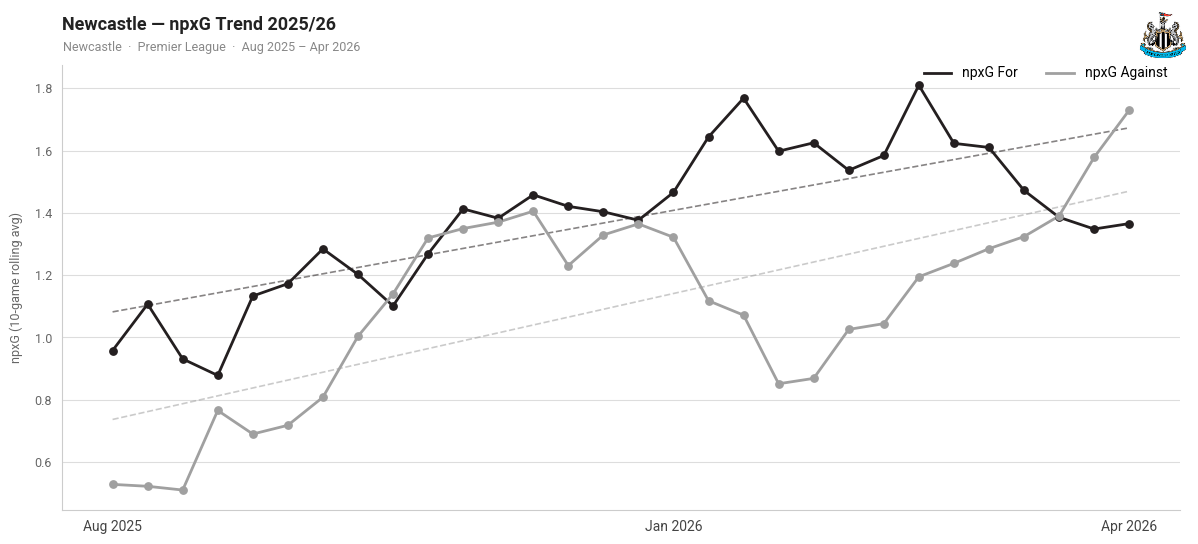

In [16]:
team = 'Newcastle'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/newcastle_npxg.png',
)

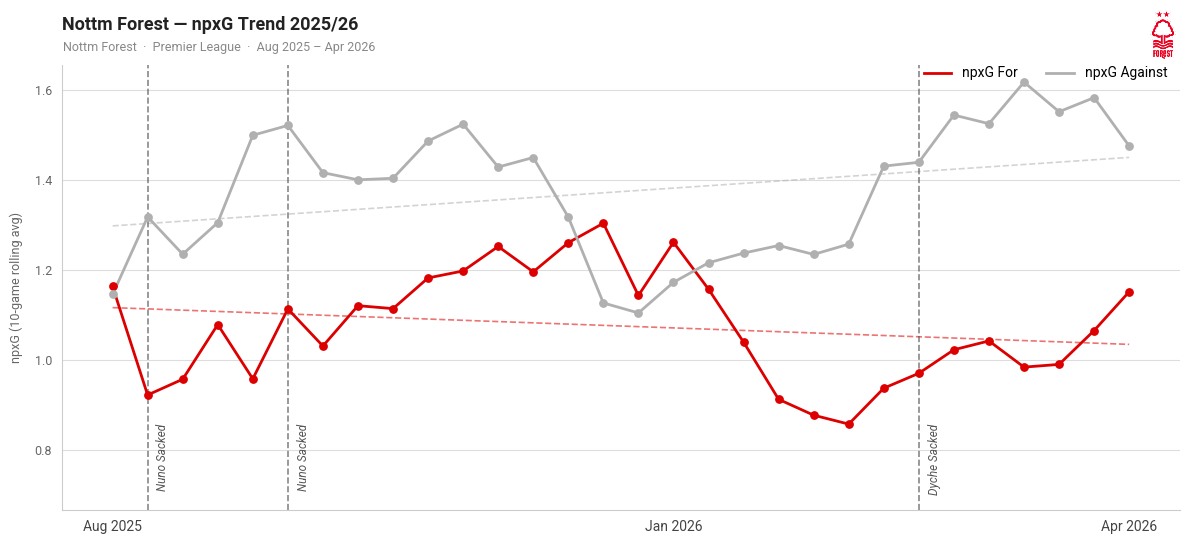

In [29]:
team = 'Nottm Forest'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    annotations = [('2025-09-09', 'Nuno Sacked'), ('2025-10-18', 'Nuno Sacked'),
                   ('2026-02-12', 'Dyche Sacked')],
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/nottm_forest_npxg.png',
)

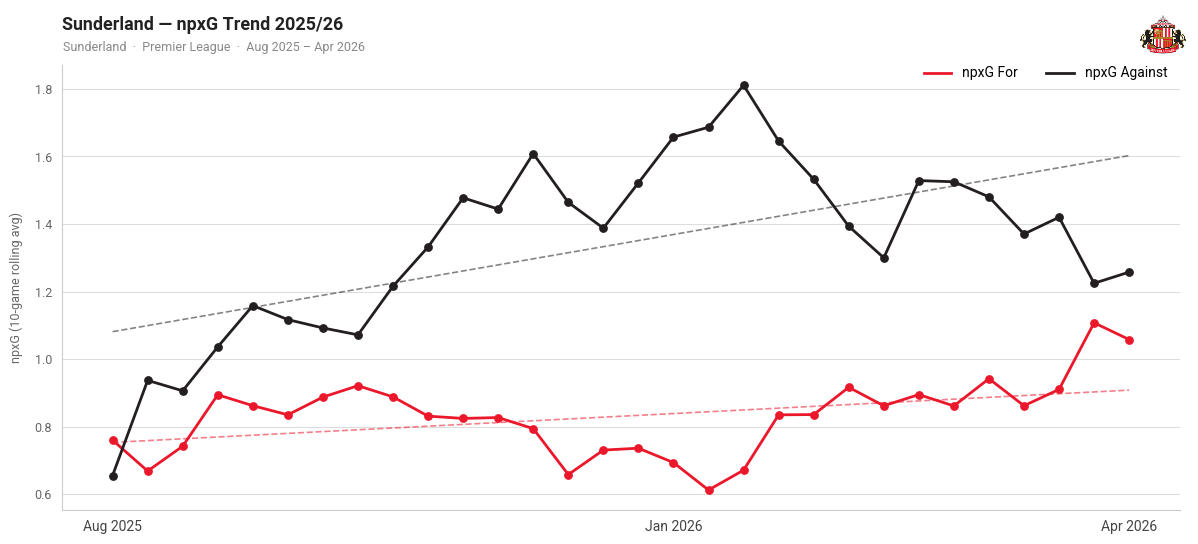

In [18]:
team = 'Sunderland'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/sunderland_npxg.png',
)

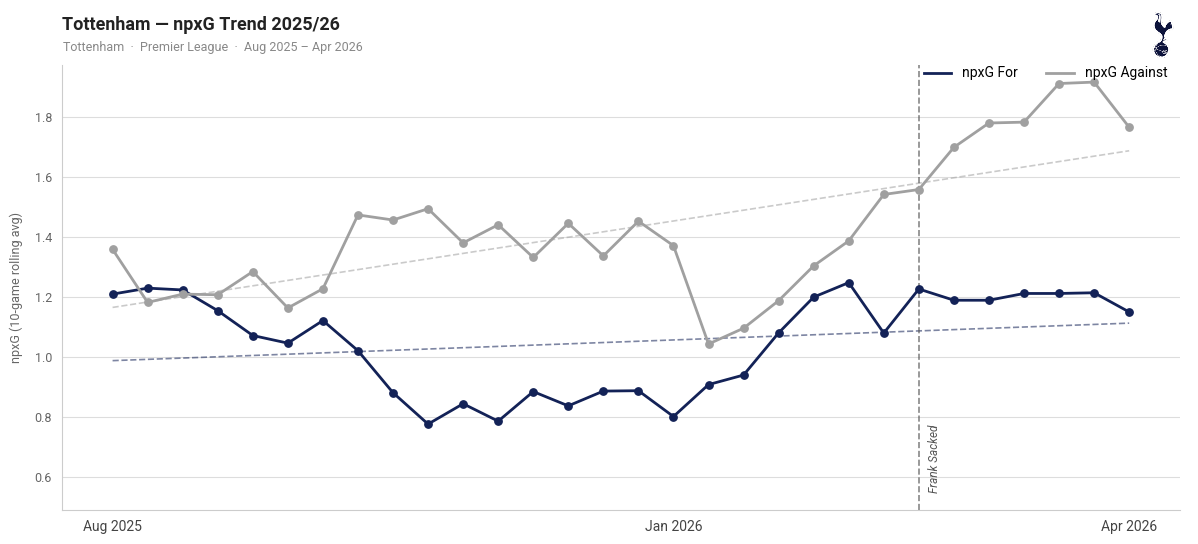

In [31]:
team = 'Tottenham'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    annotations = [('2026-02-11', 'Frank Sacked')],
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/tottenham_npxg.png',
)

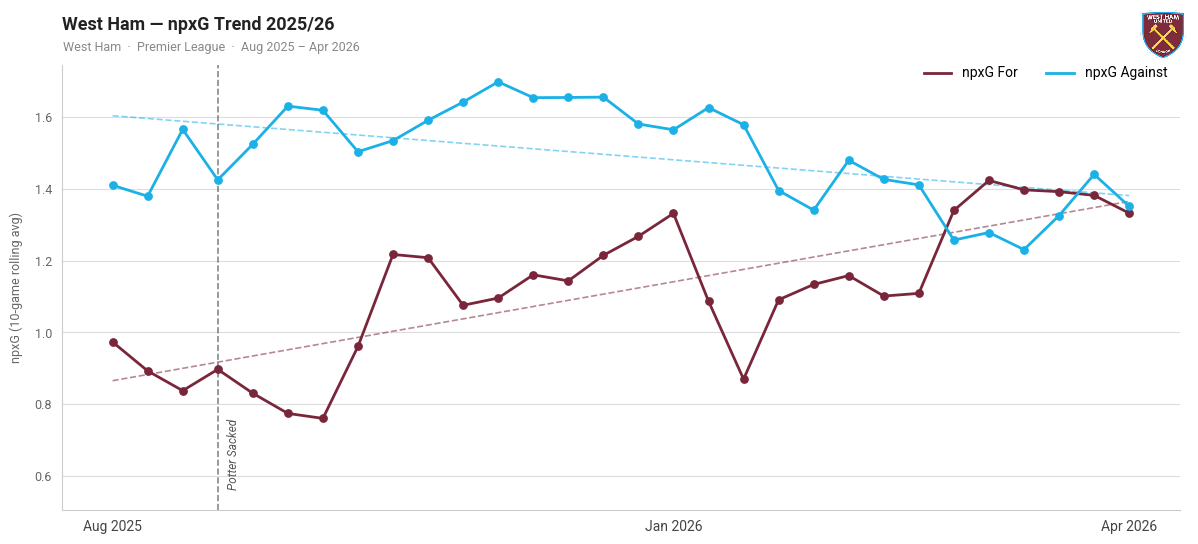

In [32]:
team = 'West Ham'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    annotations = [('2025-09-27', 'Potter Sacked')],
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/west_ham_npxg.png',
)

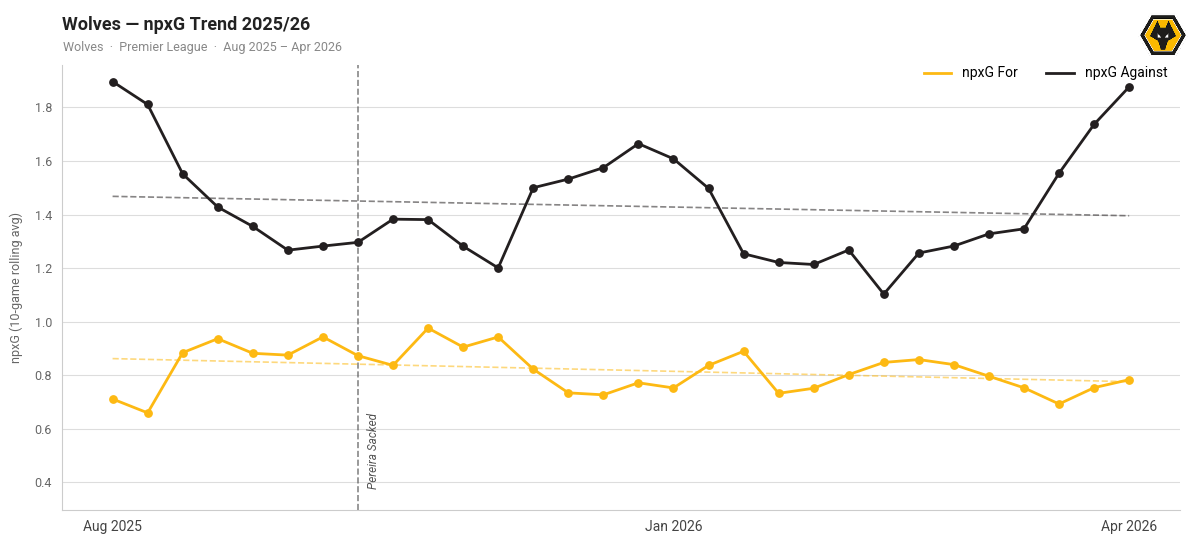

In [33]:
team = 'Wolves'
plot_df = (
    xg[xg['team_name'] == team]
    .dropna(subset=['xg_for_roll10', 'xg_against_roll10'])
    .copy()
)
plot_xg_trend(
    plot_df     = plot_df,
    title       = f"{team} — npxG Trend 2025/26",
    team        = team,
    league      = 'Premier League',
    annotations = [('2025-11-02', 'Pereira Sacked')],
    roll_n      = 10,
    extra_ticks = ['2026-01-01'],
    save_path   = '/Users/admin/dev/algobetting/analysis/power_rankings/gw32/wolves_npxg.png',
)